In [1]:
# Generate Sinusoidal Positional Encoding

import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(max_len, d_model):
    pe = np.zeros((max_len, d_model))

    for pos in range(max_len):
        for i in range(0, d_model, 2):
            pe[pos, i] = np.sin(pos / (10000 ** (i / d_model)))

            if i + 1 < d_model:
                pe[pos, i + 1] = np.cos(pos / (10000 ** (i / d_model)))

    return pe

pe = positional_encoding(max_len=100, d_model=64)

print("Shape:", pe.shape)

Shape: (100, 64)


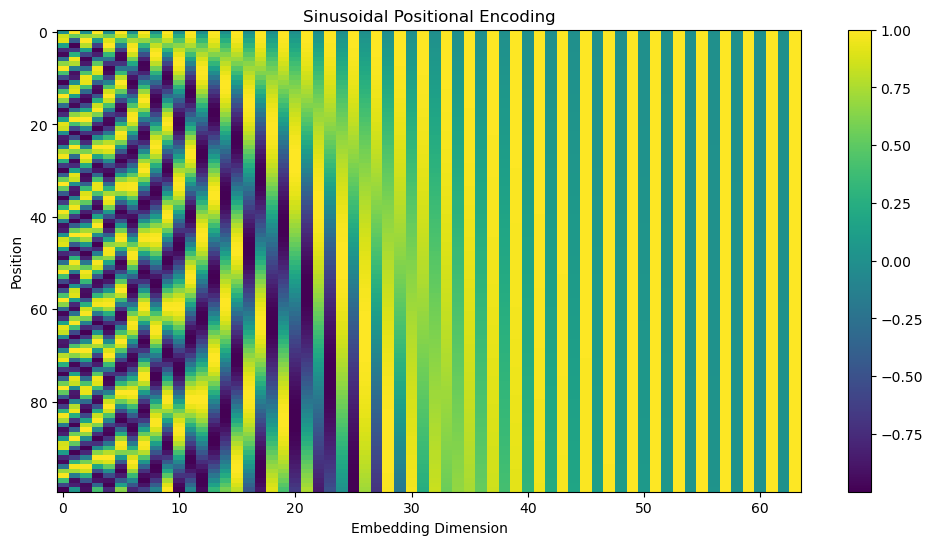

In [2]:
# Visualizing the Positional Encoding Matrix
plt.figure(figsize=(12,6))
plt.imshow(pe, cmap='viridis', aspect='auto')
plt.colorbar()
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.title("Sinusoidal Positional Encoding")
plt.show()

# Rows → token positions
# Columns → embedding dimensions
# Low dimensions change rapidly
# High dimensions change slowly

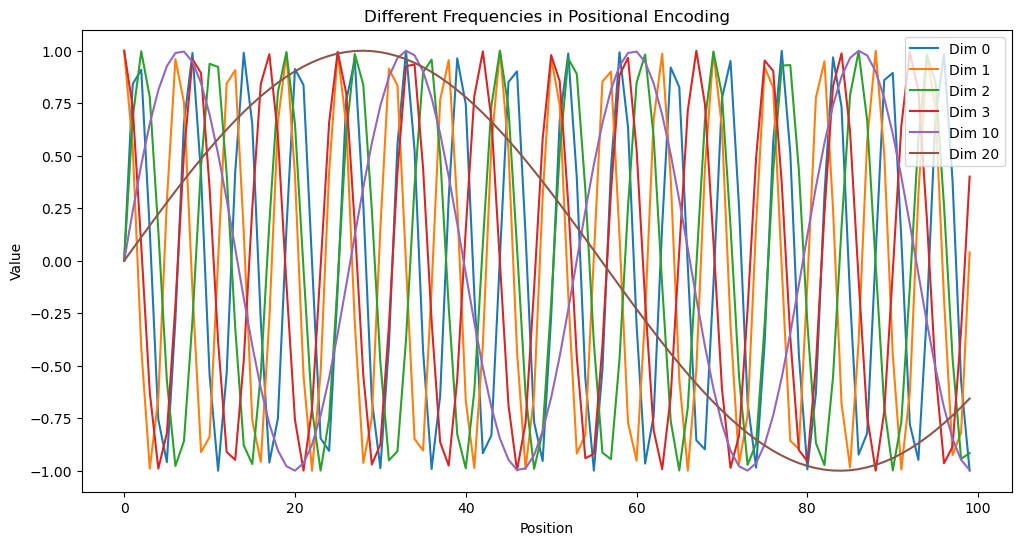

In [3]:
# Visualizing Individual Dimensions
positions = np.arange(100)

plt.figure(figsize=(12,6))

for dim in [0, 1, 2, 3, 10, 20]:
    plt.plot(positions, pe[:, dim], label=f"Dim {dim}")

plt.legend()
plt.xlabel("Position")
plt.ylabel("Value")
plt.title("Different Frequencies in Positional Encoding")
plt.show()

# Different dimensions encode position at different frequencies.
# Together they uniquely represent position.

In [ ]:
# Why Position Matters

## Suppose two sentences have identical word embeddings but different order.

In [6]:
import numpy as np

np.random.seed(42)

# Three words
word_A = np.random.randn(8)
word_B = np.random.randn(8)
word_C = np.random.randn(8)

# Sentence 1: A B C
sentence1 = np.array([
    word_A,
    word_B,
    word_C
])

# Sentence 2: C B A
sentence2 = np.array([
    word_C,
    word_B,
    word_A
])

# Positional encoding
pe_small = positional_encoding(3, 8)

# Add positional encoding
sentence1_pe = sentence1 + pe_small
sentence2_pe = sentence2 + pe_small

In [11]:
print("Sentence 1:")
print(sentence1_pe.round(3))

print("\nSentence 2:")
print(sentence2_pe.round(3))

Sentence 1:
[[ 0.497  0.862  0.648  2.523 -0.234  0.766  1.579  1.767]
 [ 0.372  1.083 -0.364  0.529  0.252 -0.913 -1.724  0.438]
 [-0.104 -0.102 -0.709 -0.432  1.486  0.774  0.07  -0.425]]

Sentence 2:
[[-1.013  1.314 -0.908 -0.412  1.466  0.774  0.068 -0.425]
 [ 0.372  1.083 -0.364  0.529  0.252 -0.913 -1.724  0.438]
 [ 1.406 -0.554  0.846  2.503 -0.214  0.766  1.581  1.767]]


In [8]:
print("Word A original embedding:")
print(word_A.round(3))

print("\nWord A at position 0:")
print((word_A + pe_small[0]).round(3))

print("\nWord A at position 2:")
print((word_A + pe_small[2]).round(3))

Word A original embedding:
[ 0.497 -0.138  0.648  1.523 -0.234 -0.234  1.579  0.767]

Word A at position 0:
[ 0.497  0.862  0.648  2.523 -0.234  0.766  1.579  1.767]

Word A at position 2:
[ 1.406 -0.554  0.846  2.503 -0.214  0.766  1.581  1.767]


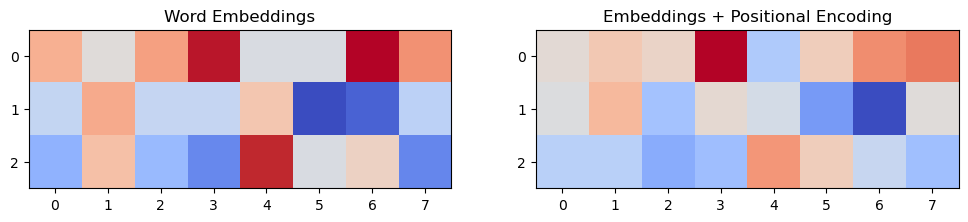

In [12]:
# Heatmap of Token Embeddings Before and After

fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].imshow(sentence1, cmap='coolwarm')
ax[0].set_title("Word Embeddings")

ax[1].imshow(sentence1_pe, cmap='coolwarm')
ax[1].set_title("Embeddings + Positional Encoding")

plt.show()

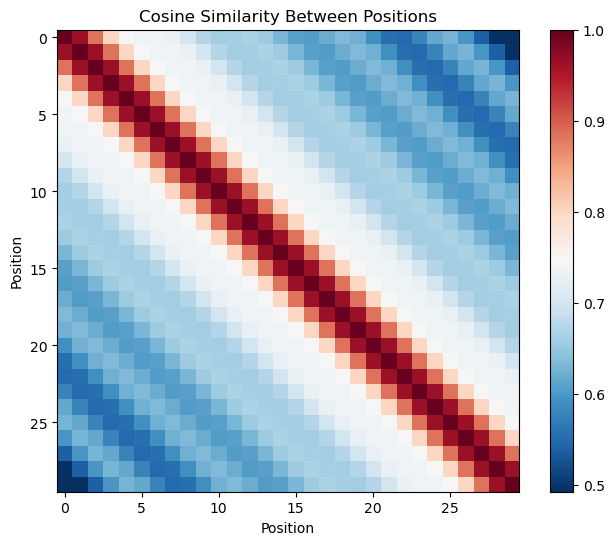

In [13]:
# Similarity Between Positions
## Every position gets a unique signature.

from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(pe[:30])

plt.figure(figsize=(8,6))
plt.imshow(sim, cmap='RdBu_r')
plt.colorbar()
plt.title("Cosine Similarity Between Positions")
plt.xlabel("Position")
plt.ylabel("Position")
plt.show()

# Nearby positions have similar encodings.
# Distant positions have different encodings.
# Transformer can infer relative distances.

In [14]:
# PyTorch Version

import torch
import math

def positional_encoding_torch(max_len, d_model):

    pe = torch.zeros(max_len, d_model)

    position = torch.arange(
        0, max_len, dtype=torch.float
    ).unsqueeze(1)

    div_term = torch.exp(
        torch.arange(0, d_model, 2).float()
        * (-math.log(10000.0) / d_model)
    )

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)

    return pe

pe = positional_encoding_torch(100, 64)

print(pe.shape)

torch.Size([100, 64])


In [ ]:
# Example
# "The cat sat on the mat"

In [15]:
# Tokenization
sentence = "The cat sat on the mat"

tokens = sentence.split()

for i, token in enumerate(tokens):
    print(f"Position {i}: {token}")

Position 0: The
Position 1: cat
Position 2: sat
Position 3: on
Position 4: the
Position 5: mat


In [16]:
# Creating Syntheic Word Embeddings

import numpy as np
import pandas as pd

np.random.seed(42)

d_model = 8

embeddings = np.random.randn(len(tokens), d_model)

df = pd.DataFrame(
    embeddings,
    index=tokens,
    columns=[f"D{i}" for i in range(d_model)]
)

df

,D0,D1,D2,D3,D4,D5,D6,D7
The,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435
cat,-0.469474,0.542560,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-0.562288
sat,-1.012831,0.314247,-0.908024,-1.412304,1.465649,-0.225776,0.067528,-1.424748
on,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694,-0.601707,1.852278
the,-0.013497,-1.057711,0.822545,-1.220844,0.208864,-1.959670,-1.328186,0.196861
mat,0.738467,0.171368,-0.115648,-0.301104,-1.478522,-0.719844,-0.460639,1.057122


In [17]:

sentence2 = "mat the on sat cat The"
tokens2 = sentence2.split()

In [18]:
print("Embedding of cat:")
print(embeddings[1])

Embedding of cat:
[-0.46947439  0.54256004 -0.46341769 -0.46572975  0.24196227 -1.91328024
 -1.72491783 -0.56228753]


In [19]:
# Positioanl EMbeddings
def positional_encoding(max_len, d_model):

    pe = np.zeros((max_len, d_model))

    for pos in range(max_len):

        for i in range(0, d_model, 2):

            pe[pos, i] = np.sin(
                pos / (10000 ** (i / d_model))
            )

            if i + 1 < d_model:
                pe[pos, i+1] = np.cos(
                    pos / (10000 ** (i / d_model))
                )

    return pe

pe = positional_encoding(len(tokens), d_model)

In [20]:
# Display Position Vectors
pe_df = pd.DataFrame(
    pe,
    index=[f"Pos {i}" for i in range(len(tokens))]
)

pe_df.round(3)

,0,1,2,3,4,5,6,7
Pos 0,0.000,1.000,0.000,1.000,0.00,1.000,0.000,1.0
Pos 1,0.841,0.540,0.100,0.995,0.01,1.000,0.001,1.0
Pos 2,0.909,-0.416,0.199,0.980,0.02,1.000,0.002,1.0
Pos 3,0.141,-0.990,0.296,0.955,0.03,1.000,0.003,1.0
Pos 4,-0.757,-0.654,0.389,0.921,0.04,0.999,0.004,1.0
Pos 5,-0.959,0.284,0.479,0.878,0.05,0.999,0.005,1.0


In [21]:
# Add Position to Embedding
final_embeddings = embeddings + pe

In [22]:
final_df = pd.DataFrame(
    final_embeddings,
    index=tokens,
    columns=[f"D{i}" for i in range(d_model)]
)

final_df.round(3)

,D0,D1,D2,D3,D4,D5,D6,D7
The,0.497,0.862,0.648,2.523,-0.234,0.766,1.579,1.767
cat,0.372,1.083,-0.364,0.529,0.252,-0.913,-1.724,0.438
sat,-0.104,-0.102,-0.709,-0.432,1.486,0.774,0.070,-0.425
on,-0.403,-0.879,-0.855,1.331,-0.571,0.708,-0.599,2.852
the,-0.770,-1.711,1.212,-0.300,0.249,-0.960,-1.324,1.197
mat,-0.220,0.455,0.364,0.576,-1.429,0.279,-0.456,2.057


In [ ]:
# Comparing

In [ ]:
The cat sat on the mat
The sat on the cat mat

In [23]:
cat_embedding = embeddings[1]

print("Original cat embedding:")
print(cat_embedding)

print("\nCat at position 1:")
print(cat_embedding + pe[1])

print("\nCat at position 4:")
print(cat_embedding + pe[4])

Original cat embedding:
[-0.46947439  0.54256004 -0.46341769 -0.46572975  0.24196227 -1.91328024
 -1.72491783 -0.56228753]

Cat at position 1:
[ 0.3719966   1.08286235 -0.36358428  0.52927441  0.2519621  -0.91333024
 -1.72391783  0.43771197]

Cat at position 4:
[-1.22627688 -0.11108358 -0.07399935  0.45533124  0.28195161 -0.91408014
 -1.72091784  0.43770447]


In [ ]:
#Observation

The word is the same.
            cat

The embedding is the same.
But after positional encoding:

cat @ position 1 ≠ cat @ position 4

This is how the Transformer knows where words occur.

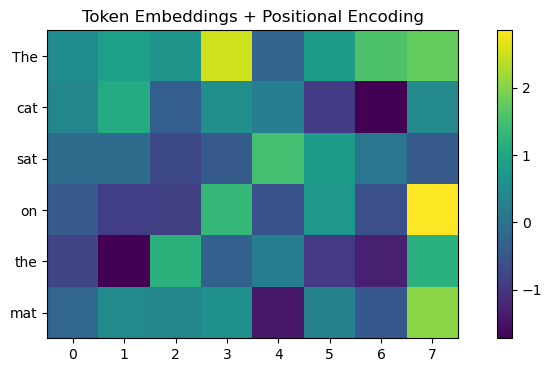

In [24]:
# Heatmap Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.imshow(final_embeddings, cmap="viridis")

plt.xticks(range(d_model))
plt.yticks(range(len(tokens)), tokens)

plt.colorbar()
plt.title("Token Embeddings + Positional Encoding")

plt.show()